2026-03-27 22:09:01 - 01_hh_analysis - INFO - Ноутбук запущен
2026-03-27 22:09:01 - 01_hh_analysis - INFO - Загружено 55 навыков


2026-03-27 22:09:01 - 01_hh_analysis - INFO - Загружен маппинг для 44 компетенций
C:\Users\максим\AppData\Local\Temp\ipykernel_6284\1770599960.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=skills, palette="viridis")


Загружено 55 уникальных навыков с частотами.
Загружен маппинг для 44 компетенций.

Пример навыков и их частот:
sql: 20
ms excel: 19
linux: 16
crm: 15
docker: 13
системный анализ: 13
бизнес-анализ: 10
git: 9
postgresql: 9
английский язык: 8

Всего упоминаний навыков: 274
Уникальных навыков: 55


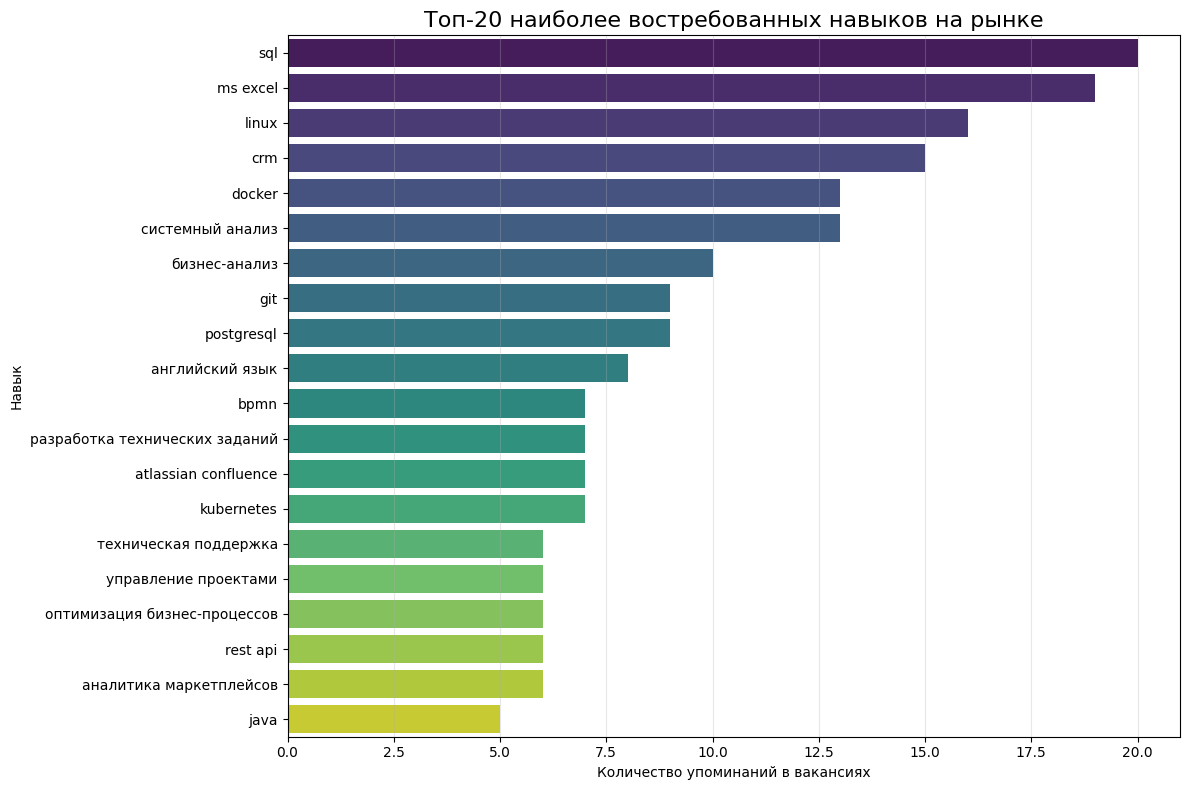

Успешно сопоставлено 12 учебных компетенций


C:\Users\максим\AppData\Local\Temp\ipykernel_6284\1770599960.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=comp_counts, y=comp_names, palette="magma")


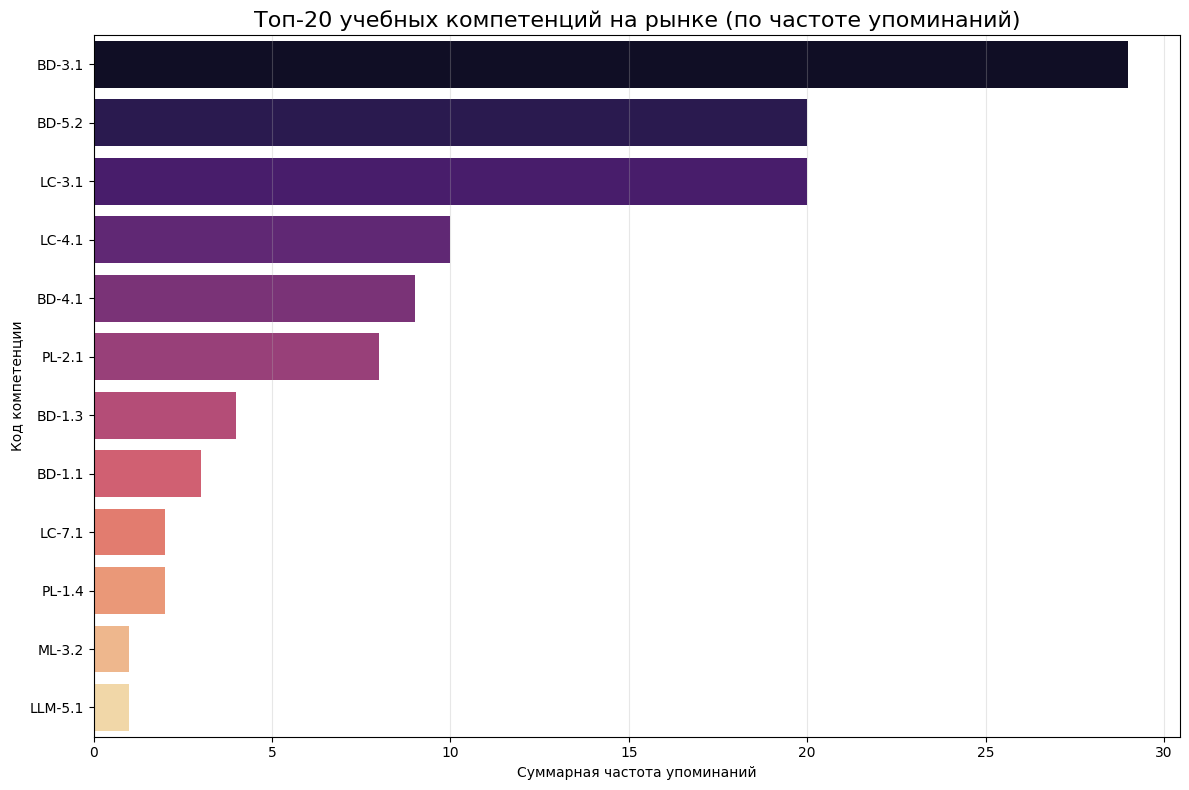

In [ ]:
# %% [markdown]
# ### 1. Подготовка окружения
# %%
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.config import DATA_PROCESSED_DIR
from src.utils import get_logger, load_competency_mapping

logger = get_logger("01_hh_analysis")
logger.info("Ноутбук запущен")

# %% [markdown]
# ### 2. Загрузка данных

# %%
freq_path = DATA_PROCESSED_DIR / "competency_frequency.json"
if not freq_path.exists():
    logger.error(f"Файл {freq_path} не найден")
    raise FileNotFoundError(...)

with open(freq_path, 'r', encoding='utf-8') as f:
    skill_freq = json.load(f)

logger.info(f"Загружено {len(skill_freq)} навыков")

mapping = load_competency_mapping()
if not mapping:
    logger.warning("Маппинг пуст")
else:
    logger.info(f"Загружен маппинг для {len(mapping)} компетенций")
# %% [markdown]
# ### 3. Статистика и примеры навыков

# %%
total_mentions = sum(skill_freq.values())
unique_skills = len(skill_freq)

print(f"Загружено {unique_skills} уникальных навыков с частотами.")
print(f"Загружен маппинг для {len(mapping)} компетенций.\n")

print("Пример навыков и их частот:")
top_example = sorted(skill_freq.items(), key=lambda x: x[1], reverse=True)[:10]
for skill, count in top_example:
    print(f"{skill}: {count}")

print(f"\nВсего упоминаний навыков: {total_mentions}")
print(f"Уникальных навыков: {unique_skills}")


# %% [markdown]
# ### 4. Визуализация топ-20 востребованных навыков

# %%
top_skills = sorted(skill_freq.items(), key=lambda x: x[1], reverse=True)[:20]
skills, counts = zip(*top_skills)

plt.figure(figsize=(12, 8))
sns.barplot(x=counts, y=skills, hue=skills, palette="viridis", legend=False)
plt.title("Топ-20 наиболее востребованных навыков на рынке", fontsize=16)
plt.xlabel("Количество упоминаний в вакансиях")
plt.ylabel("Навык")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


# %% [markdown]
# ### 5. Топ учебных компетенций на рынке (после маппинга)

# %%
# Преобразуем рыночные навыки в учебные компетенции
comp_counter = Counter()

for skill, freq in skill_freq.items():
    normalized_skill = skill.lower().strip()
    found = False
    for comp_code, keywords in mapping.items():
        for kw in keywords:
            if kw.lower() in normalized_skill or normalized_skill in kw.lower():
                comp_counter[comp_code] += freq
                found = True
                break
        if found:
            break

print(f"Успешно сопоставлено {len(comp_counter)} учебных компетенций")

# Топ-20 компетенций
top_comp = comp_counter.most_common(20)
comp_names, comp_counts = zip(*top_comp)

plt.figure(figsize=(12, 8))
sns.barplot(x=comp_counts, y=comp_names, hue=comp_names, palette="magma", legend=False)
plt.title("Топ-20 учебных компетенций на рынке (по частоте упоминаний)", fontsize=16)
plt.xlabel("Суммарная частота упоминаний")
plt.ylabel("Код компетенции")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()